# NB08 — Synthesis figure

Multi-panel summary of the Harvard Forest warming response across taxonomy, function (DNA + RNA), and metabolites.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
USER_DIR = os.path.abspath('../user_data')

design        = pd.read_csv(os.path.join(DATA_DIR, 'sample_design.tsv'), sep='\t')
phylum_de     = pd.read_csv(os.path.join(DATA_DIR, '03_phylum_treatment_tests.tsv'), sep='\t')
permanova_dna_rna = pd.read_csv(os.path.join(DATA_DIR, '04_permanova_dna_rna.tsv'), sep='\t')
h1_sens       = pd.read_csv(os.path.join(DATA_DIR, '05_h1_sensitivity_direct.tsv'), sep='\t')
c_enrich      = pd.read_csv(os.path.join(DATA_DIR, '05_c_cycling_enrichment.tsv'), sep='\t')
DA            = pd.read_csv(os.path.join(DATA_DIR, '05_da_per_ko_per_pool_per_horizon.tsv.gz'),
                            sep='\t', compression='gzip')
c_kos         = pd.read_csv(os.path.join(USER_DIR, 'c_cycling_kos.tsv'), sep='\t')
metab_count   = pd.read_csv(os.path.join(DATA_DIR, '07_chebi_count_per_sample.tsv'), sep='\t', index_col=0)
print('Loaded inputs.')

Loaded inputs.


/tmp/ipykernel_23394/3480120776.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


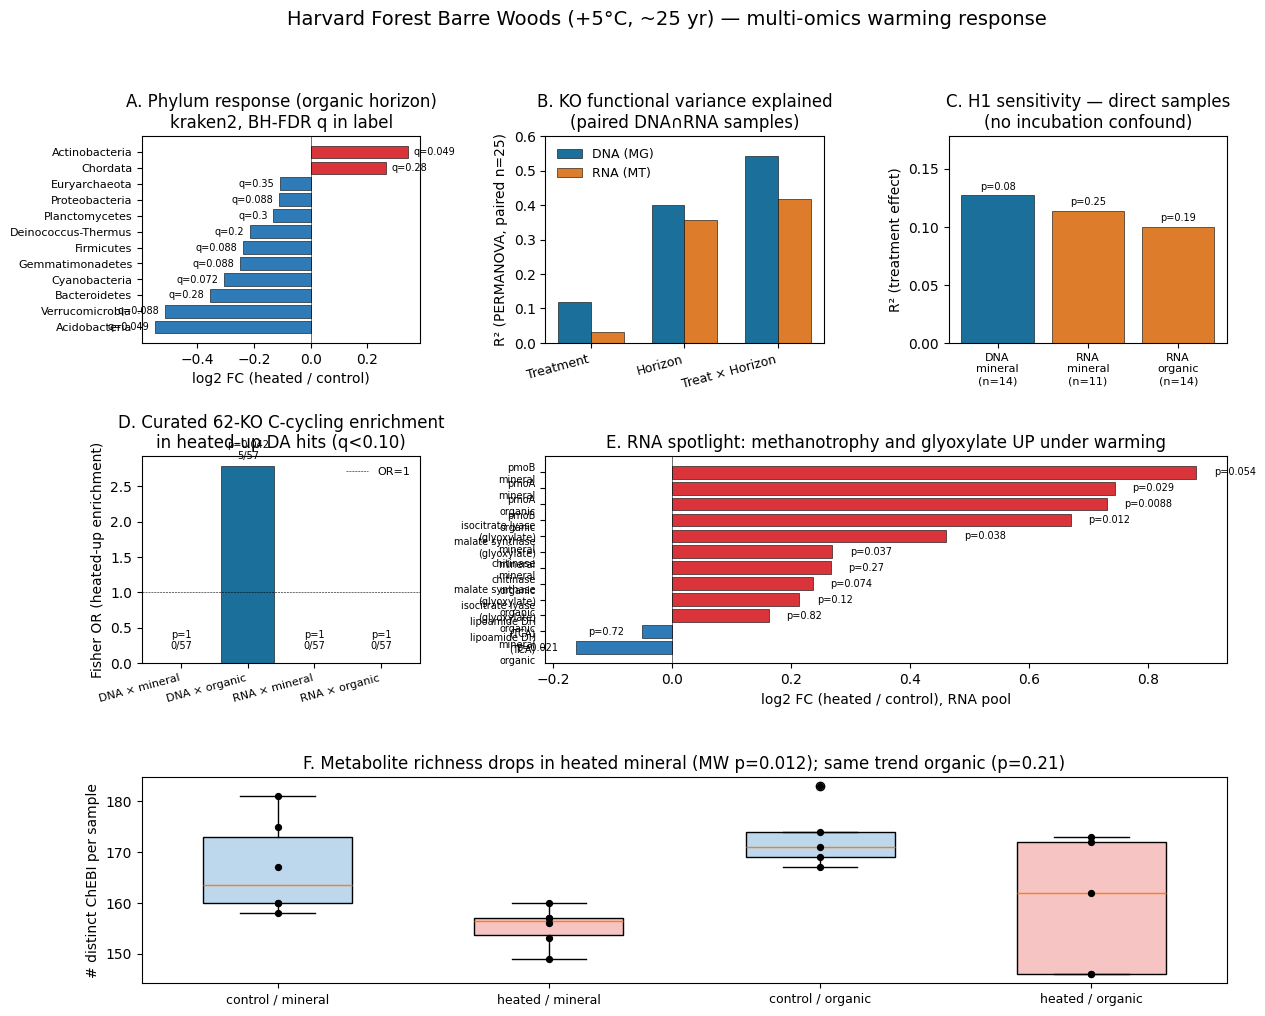

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/08_synthesis.png


In [2]:
fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(3, 3, hspace=0.55, wspace=0.45, figure=fig)
ax_a = fig.add_subplot(gs[0, 0])  # Phylum effect
ax_b = fig.add_subplot(gs[0, 1])  # PERMANOVA R^2 by factor
ax_c = fig.add_subplot(gs[0, 2])  # H1 sensitivity
ax_d = fig.add_subplot(gs[1, 0])  # C-cycling enrichment
ax_e = fig.add_subplot(gs[1, 1:]) # pmoA/pmoB + glyoxylate spotlight
ax_f = fig.add_subplot(gs[2, :])  # Metabolite richness by treatment x horizon

# ----- Panel A: Phylum-level treatment effect (organic horizon) -----
phy_org = phylum_de[phylum_de['horizon'] == 'organic'].sort_values('log2_fc')
colors = ['#d9343a' if x > 0 else '#2e7bb8' for x in phy_org['log2_fc']]
stars = ['**' if q < 0.05 else ('*' if q < 0.10 else '') for q in phy_org['q']]
ax_a.barh(np.arange(len(phy_org)), phy_org['log2_fc'], color=colors, edgecolor='black', linewidth=0.4)
ax_a.set_yticks(np.arange(len(phy_org)))
ax_a.set_yticklabels([s.strip() for s in phy_org['phylum']], fontsize=8)
ax_a.axvline(0, color='black', linewidth=0.4)
ax_a.set_xlabel('log2 FC (heated / control)')
ax_a.set_title('A. Phylum response (organic horizon)\nkraken2, BH-FDR q in label')
for i, (_, r) in enumerate(phy_org.iterrows()):
    ax_a.text(r['log2_fc'] + (0.02 if r['log2_fc'] >= 0 else -0.02),
              i, f"q={r['q']:.2g}", va='center',
              ha='left' if r['log2_fc'] >= 0 else 'right', fontsize=7)

# ----- Panel B: PERMANOVA R^2 by factor in DNA vs RNA -----
perm = permanova_dna_rna[permanova_dna_rna['factor'].isin(['treatment', 'horizon', 'treatment_x_horizon'])]
perm = perm.copy()
perm['factor'] = perm['factor'].map({
    'treatment': 'Treatment',
    'horizon': 'Horizon',
    'treatment_x_horizon': 'Treat × Horizon',
})
wide = perm.pivot(index='factor', columns='pool', values='R2').reindex(['Treatment', 'Horizon', 'Treat × Horizon'])
x = np.arange(len(wide))
w = 0.35
ax_b.bar(x - w/2, wide['DNA'], w, label='DNA (MG)', color='#1b6f9b', edgecolor='black', linewidth=0.4)
ax_b.bar(x + w/2, wide['RNA'], w, label='RNA (MT)', color='#dd7d2c', edgecolor='black', linewidth=0.4)
ax_b.set_xticks(x)
ax_b.set_xticklabels(wide.index, rotation=15, ha='right', fontsize=9)
ax_b.set_ylabel('R² (PERMANOVA, paired n=25)')
ax_b.set_title('B. KO functional variance explained\n(paired DNA∩RNA samples)')
ax_b.legend(frameon=False, fontsize=9)
ax_b.set_ylim(0, 0.6)

# ----- Panel C: H1 sensitivity (direct samples only) -----
h1 = h1_sens.dropna(subset=['R2']).copy()
h1['label'] = h1['pool'] + '\n' + h1['horizon'] + '\n(n=' + h1['n'].astype(str) + ')'
colors_h1 = ['#1b6f9b' if p == 'DNA' else '#dd7d2c' for p in h1['pool']]
ax_c.bar(range(len(h1)), h1['R2'], color=colors_h1, edgecolor='black', linewidth=0.4)
ax_c.set_xticks(range(len(h1)))
ax_c.set_xticklabels(h1['label'], fontsize=8)
ax_c.set_ylabel('R² (treatment effect)')
ax_c.set_title('C. H1 sensitivity — direct samples\n(no incubation confound)')
for i, (_, r) in enumerate(h1.iterrows()):
    ax_c.text(i, r['R2'] + 0.005, f"p={r['p']:.2f}", ha='center', fontsize=7)
ax_c.set_ylim(0, max(h1['R2']) * 1.4 if len(h1) else 0.2)

# ----- Panel D: C-cycling enrichment OR -----
ce = c_enrich.copy()
ce['label'] = ce['pool'] + ' × ' + ce['horizon']
ce['OR_plot'] = ce['OR'].fillna(0)
colors_d = ['#1b6f9b' if p == 'DNA' else '#dd7d2c' for p in ce['pool']]
bars = ax_d.bar(range(len(ce)), ce['OR_plot'], color=colors_d, edgecolor='black', linewidth=0.4)
ax_d.axhline(1, color='black', linewidth=0.4, linestyle='--', label='OR=1')
ax_d.set_xticks(range(len(ce)))
ax_d.set_xticklabels(ce['label'], rotation=15, ha='right', fontsize=8)
ax_d.set_ylabel('Fisher OR (heated-up enrichment)')
ax_d.set_title('D. Curated 62-KO C-cycling enrichment\nin heated-up DA hits (q<0.10)')
for i, (_, r) in enumerate(ce.iterrows()):
    label = f"p={r['p_one_sided']:.2g}\n{int(r['n_c_hit'])}/{int(r['n_c_total'])}"
    ax_d.text(i, max(r['OR_plot'] + 0.1, 0.2), label, ha='center', fontsize=7)
ax_d.legend(frameon=False, fontsize=8)

# ----- Panel E: pmoA/pmoB and glyoxylate spotlight -----
spotlight_kos = {
    'K10944': 'pmoA',
    'K10945': 'pmoB',
    'K01637': 'isocitrate lyase\n(glyoxylate)',
    'K01638': 'malate synthase\n(glyoxylate)',
    'K01183': 'chitinase',
    'K00382': 'lipoamide DH\n(TCA)',
}
spot = DA[(DA['ko'].isin(spotlight_kos.keys())) & (DA['pool'] == 'RNA')].copy()
spot['label'] = spot['ko'].map(spotlight_kos) + '\n' + spot['horizon']
spot = spot.sort_values('log2_fc')
colors_e = ['#d9343a' if x > 0 else '#2e7bb8' for x in spot['log2_fc']]
ax_e.barh(np.arange(len(spot)), spot['log2_fc'], color=colors_e, edgecolor='black', linewidth=0.4)
ax_e.set_yticks(np.arange(len(spot)))
ax_e.set_yticklabels(spot['label'], fontsize=7)
ax_e.axvline(0, color='black', linewidth=0.4)
ax_e.set_xlabel('log2 FC (heated / control), RNA pool')
ax_e.set_title('E. RNA spotlight: methanotrophy and glyoxylate UP under warming')
for i, (_, r) in enumerate(spot.iterrows()):
    ax_e.text(r['log2_fc'] + (0.03 if r['log2_fc'] >= 0 else -0.03),
              i, f"p={r['p']:.2g}", va='center',
              ha='left' if r['log2_fc'] >= 0 else 'right', fontsize=7)

# ----- Panel F: Per-sample metabolite richness -----
mc = metab_count.dropna(subset=['n_distinct_chebi'])
mc = mc.copy()
mc['cell'] = mc['treatment'] + ' / ' + mc['horizon']
cell_order = ['control / mineral', 'heated / mineral', 'control / organic', 'heated / organic']
data = [mc[mc['cell'] == c]['n_distinct_chebi'].values for c in cell_order]
bplot = ax_f.boxplot(data, tick_labels=cell_order, patch_artist=True, widths=0.55)
for patch, c in zip(bplot['boxes'], ['#bdd7ed', '#f7c4c4', '#bdd7ed', '#f7c4c4']):
    patch.set_facecolor(c); patch.set_edgecolor('black')
for i, arr in enumerate(data):
    ax_f.scatter([i + 1] * len(arr), arr, color='black', s=18, zorder=3)
ax_f.set_ylabel('# distinct ChEBI per sample')
ax_f.set_title('F. Metabolite richness drops in heated mineral (MW p=0.012); same trend organic (p=0.21)')
for label in ax_f.get_xticklabels():
    label.set_fontsize(9)

fig.suptitle('Harvard Forest Barre Woods (+5°C, ~25 yr) — multi-omics warming response',
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
out = os.path.join(FIG_DIR, '08_synthesis.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Wrote {out}')

## Story summary

| Hypothesis | Verdict | Evidence |
|------------|---------|----------|
| H1: RNA shifts more than DNA under warming | **Not supported** | Direct-sample sensitivity (NB05): R²=12.7% (DNA min) vs 11.4% (RNA min) vs 10.0% (RNA org); paired NB04 result was a horizon×incubation confound. |
| H2: C-cycling KOs enriched in heated | **Partially supported** | Fisher OR=2.78, p=0.042 in DNA organic. Methanotrophy (pmoA/pmoB) UP +0.7-0.9 log2FC in RNA both horizons. Glyoxylate cycle UP in heated mineral RNA. |
| H3: Horizon × warming interaction | **Supported (compositional)** | Most KO-level warming responses are horizon-specific (Spearman ρ=0.22 DNA, 0.12 RNA). C-cycling not differentially enriched in horizon-specific classes. |
| Bonus: Metabolite richness | Heated soils have **fewer detectable metabolites** in mineral horizon (155 vs 167, MW p=0.012). |
| Community-level | Actinobacteria UP +34%, Acidobacteria DOWN −55% in heated organic (q=0.049 each) — matches published Pold et al. findings. |
